<a href="https://colab.research.google.com/github/sharrenepf/Tugas-PCVK_Sharren/blob/main/Week5_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import platform
import hashlib
import datetime
import zoneinfo

NAMA = 'Sharren Elvaretta'
NIM = '244107020191'
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)

for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())

kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Sharren Elvaretta
NIM : 244107020191 | N = 191
bins   : 64
clip   : 1.5
tile   : 5
L      : 8
WAKTU : 2026-09-25 12:20:35 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 5e1b0f15d00db457


Percobaan Praktikum 1

In [2]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Lenna.png to Lenna.png


In [6]:
import cv2 as cv
import matplotlib.pyplot as plt

gray = cv.imread('/content/Lenna.png', cv.IMREAD_GRAYSCALE)

if gray is None:
    raise FileNotFoundError("File Lenna.png tidak berhasil dibaca.")

print("Ukuran citra :", gray.shape)
print("Tipe data    :", gray.dtype)

Ukuran citra : (456, 456)
Tipe data    : uint8


In [10]:
NAMA = 'Sharren Elvaretta Pratamadya Fianto'
NIM = '244107020191'

print('NAMA :', NAMA)
print('NIM  :', NIM)

NAMA : Sharren Elvaretta Pratamadya Fianto
NIM  : 244107020191


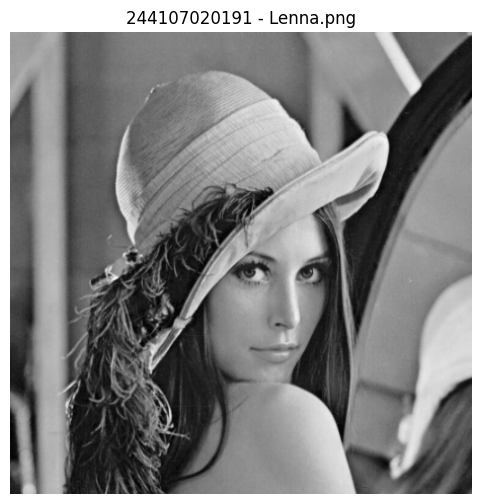

In [11]:
plt.figure(figsize=(6, 6))

plt.imshow(gray, cmap='gray')
plt.title(NIM + ' - Lenna.png')
plt.axis('off')

plt.show()

In [12]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [13]:
h_manual = histogram_manual(gray)

print("Jumlah piksel       :", gray.size)
print("Jumlah histogram    :", h_manual.sum())

assert h_manual.sum() == gray.size

print("Histogram manual benar.")

Jumlah piksel       : 207936
Jumlah histogram    : 207936
Histogram manual benar.


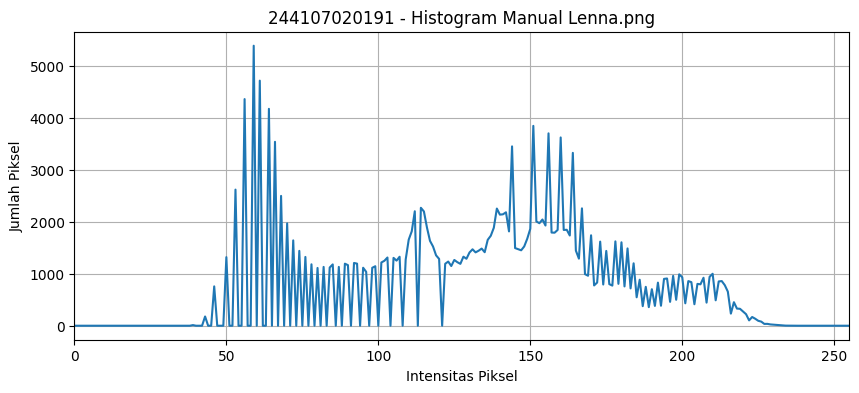

In [14]:
plt.figure(figsize=(10, 4))

plt.plot(h_manual)

plt.title(NIM + ' - Histogram Manual Lenna.png')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])
plt.grid()

plt.show()

Pertanyaan


In [15]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [16]:
gray = cv.imread('/content/Lenna.png', cv.IMREAD_GRAYSCALE)

h_manual = histogram_manual(gray)

h_numpy, bin_edges = np.histogram(
    gray,
    bins=256,
    range=(0, 256)
)

h_cv = cv.calcHist(
    [gray],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

h_cv = h_cv.astype(np.int64)

In [18]:
selisih_manual_numpy = np.max(
    np.abs(h_manual - h_numpy)
)

selisih_manual_cv = np.max(
    np.abs(h_manual - h_cv)
)

selisih_numpy_cv = np.max(
    np.abs(h_numpy - h_cv)
)

print("Selisih maksimum Manual vs NumPy :", selisih_manual_numpy)
print("Selisih maksimum Manual vs OpenCV:", selisih_manual_cv)
print("Selisih maksimum NumPy vs OpenCV :", selisih_numpy_cv)

Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs OpenCV: 0
Selisih maksimum NumPy vs OpenCV : 0


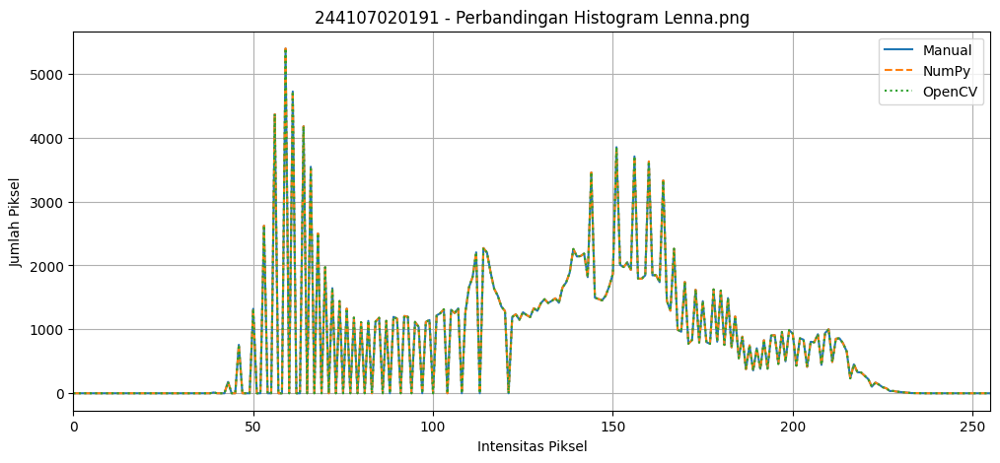

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(h_manual, label='Manual')
plt.plot(h_numpy, '--', label='NumPy')
plt.plot(h_cv, ':', label='OpenCV')

plt.title(NIM + ' - Perbandingan Histogram Lenna.png')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim(0, 255)
plt.legend()
plt.grid()

plt.show()

Jawaban E1.1

Berdasarkan hasil pengujian, histogram yang dibuat secara manual, menggunakan numpy.histogram, dan menggunakan cv.calcHist menghasilkan distribusi frekuensi piksel yang sama. Selisih maksimum antara histogram manual dengan NumPy, manual dengan OpenCV, serta NumPy dengan OpenCV adalah 0. Dengan demikian, implementasi histogram manual telah sesuai dengan hasil library NumPy dan OpenCV.

Jawaban E1.2 — Histogram Normalisasi dan CDF KTM1a–KTM1d

Sekarang kita masuk ke bagian yang membutuhkan empat foto KTM milikmu.

Modul meminta histogram ternormalisasi p(j) dan kurva CDF untuk KTM1a.jpg sampai KTM1d.jpg dalam satu figure 2×2. Kemudian dianalisis perbedaan citra paling gelap dan paling terang berdasarkan kondisi pencahayaan.

In [20]:
def histogram_cdf(img):
    h = histogram_manual(img)

    p = h / img.size
    cdf = np.cumsum(p)

    return h, p, cdf

In [25]:
files = [
    'KTM1a.jpg',
    'KTM1b.jpg',
    'KTM1c.jpg',
    'KTM1d.jpg'
]

images = []

for file in files:
    path = BASE + '/' + file
    img = cv.imread(path, cv.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(
            f'Citra tidak ditemukan: {path}'
        )

    images.append(img)

print("Semua citra berhasil dibaca.")

Semua citra berhasil dibaca.


In [24]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


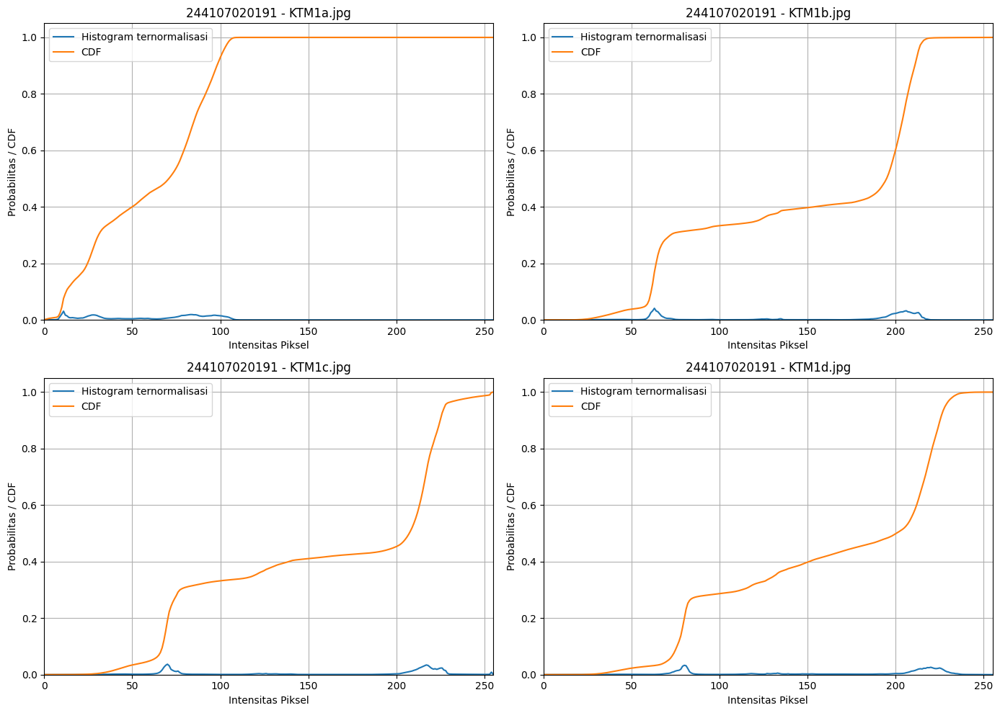

In [26]:
plt.figure(figsize=(14, 10))

for i, (file, img) in enumerate(zip(files, images), 1):
    h, p, cdf = histogram_cdf(img)

    plt.subplot(2, 2, i)

    plt.plot(p, label='Histogram ternormalisasi')
    plt.plot(cdf, label='CDF')

    plt.title(NIM + ' - ' + file)
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Probabilitas / CDF')
    plt.xlim(0, 255)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid()

plt.tight_layout()
plt.show()

In [27]:
for file, img in zip(files, images):
    h, p, cdf = histogram_cdf(img)

    print(
        file,
        "| mean =", round(img.mean(), 2),
        "| min =", img.min(),
        "| max =", img.max(),
        "| median =", np.median(img)
    )

KTM1a.jpg | mean = 60.33 | min = 0 | max = 117 | median = 71.0
KTM1b.jpg | mean = 150.94 | min = 5 | max = 255 | median = 195.0
KTM1c.jpg | mean = 160.01 | min = 0 | max = 255 | median = 208.0
KTM1d.jpg | mean = 163.41 | min = 7 | max = 254 | median = 201.0


Untuk foto:

KTM1a → ruangan gelap

KTM1b → pencahayaan lampu ruangan

KTM1c → menggunakan flash

KTM1d → cahaya matahari luar ruangan

Citra dengan pencahayaan paling gelap memiliki distribusi histogram yang lebih terkonsentrasi pada intensitas rendah dan kurva CDF meningkat lebih banyak pada bagian kiri histogram. Sebaliknya, citra dengan pencahayaan paling terang memiliki distribusi yang bergeser menuju intensitas lebih tinggi sehingga kurva CDF lebih cepat meningkat pada wilayah intensitas tinggi. Perbedaan tersebut berkaitan dengan kondisi pencahayaan saat akuisisi, yaitu jumlah cahaya yang diterima kamera memengaruhi tingkat intensitas piksel pada citra.

In [29]:
NIM = '191'

PARAM = {
    'bins': 64
}

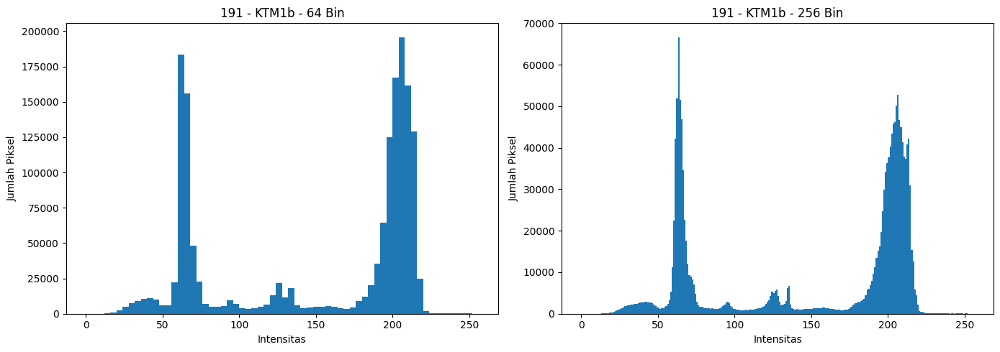

In [30]:
img = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(
        'KTM1b.jpg tidak ditemukan.'
    )

hist_64, edges_64 = np.histogram(
    img,
    bins=PARAM['bins'],
    range=(0, 256)
)

hist_256, edges_256 = np.histogram(
    img,
    bins=256,
    range=(0, 256)
)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(
    edges_64[:-1],
    hist_64,
    width=256 / PARAM['bins'],
    align='edge'
)
plt.title(NIM + ' - KTM1b - 64 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(1, 2, 2)
plt.bar(
    edges_256[:-1],
    hist_256,
    width=1,
    align='edge'
)
plt.title(NIM + ' - KTM1b - 256 Bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.tight_layout()
plt.show()

Jawaban E1.3

Histogram dengan 256 bin mempertahankan informasi intensitas secara lebih detail karena setiap bin mewakili satu nilai intensitas dari 0 sampai 255. Sementara itu, penggunaan 64 bin menggabungkan beberapa nilai intensitas ke dalam satu bin sehingga bentuk distribusi menjadi lebih sederhana dan lebih mudah melihat pola umum.

Informasi yang hilang ketika jumlah bin dikurangi adalah detail variasi intensitas piksel. Perbedaan kecil antarintensitas dapat tergabung dalam bin yang sama sehingga detail lokal pada histogram tidak terlihat. Namun, pola distribusi intensitas secara umum masih dapat diamati.

Percobaan 2


In [31]:
def baca(path, gray=False):
    img = cv.imread(path, cv.IMREAD_GRAYSCALE if gray else cv.IMREAD_COLOR)
    assert img is not None, 'Berkas tidak ditemukan: ' + path
    return img

def rgb(bgr):
    return cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

def histogram_manual(img, L=256):            # versi perulangan dari modul (lambat, untuk bukti)
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

def hist256(ch):                             # hasil identik dengan histogram_manual, jauh lebih cepat
    return np.bincount(ch.ravel(), minlength=256).astype(np.int64)

def selisih_maks(a, b):
    return int(np.abs(a.astype(np.int32) - b.astype(np.int32)).max())

def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float('inf') if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

def entropi(ch):
    p = hist256(ch) / ch.size
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

# bukti histogram_manual == hist256 pada potongan kecil
_t = np.random.randint(0, 256, (40, 40), dtype=np.uint8)
assert (histogram_manual(_t) == hist256(_t)).all()

# ---- Histogram Equalization manual ----
def he_lut(ch, mode='modul'):
    """mode 'modul'  : Ko = round(C * 255 / (w*h))                 (rumus di modul)
       mode 'opencv' : Ko = round((C - Cmin) * 255 / (w*h - Cmin)) (rumus yang dipakai cv.equalizeHist)"""
    h = hist256(ch); cdf = np.cumsum(h); N = ch.size
    if mode == 'modul':
        return np.clip(np.rint(cdf * 255.0 / N), 0, 255).astype(np.uint8)
    first = int(np.nonzero(h)[0][0])
    lut = np.zeros(256, np.uint8)
    if h[first] == N:
        lut[:] = first
        return lut
    scale = np.float32(255.0) / np.float32(N - h[first])
    idx = np.arange(first + 1, 256)
    lut[idx] = np.clip(np.rint((cdf[idx] - h[first]).astype(np.float32) * scale), 0, 255).astype(np.uint8)
    return lut

def he_manual(ch, mode='modul'):
    return he_lut(ch, mode)[ch]

def he_manual_warna(bgr, mode='modul'):
    return cv.merge([he_manual(c, mode) for c in cv.split(bgr)])

# ---- ROI (pecahan tinggi/lebar: y0, y1, x0, x1) ----
def crop(img, f):
    H, W = img.shape[:2]; y0, y1, x0, x1 = f
    return img[int(y0 * H):int(y1 * H), int(x0 * W):int(x1 * W)]

def kotak(ax, f, warna, H, W):
    y0, y1, x0, x1 = f
    ax.add_patch(plt.Rectangle((x0 * W, y0 * H), (x1 - x0) * W, (y1 - y0) * H,
                               fill=False, ec=warna, lw=2))

In [32]:
nk = np.array([790, 1023, 850, 656, 329, 245, 122, 81])
MN = nk.sum(); assert MN == 4096
p = nk / MN; cdf = np.cumsum(p); s = 7 * cdf; sb = np.rint(s).astype(int)
print('p   :', np.round(p, 2))
print('CDF :', np.round(cdf, 2))
print('s   :', np.round(s, 2))
print('s_bulat:', sb, '-> level unik:', sorted(set(sb)), '| jumlah =', len(set(sb)))

p   : [0.19 0.25 0.21 0.16 0.08 0.06 0.03 0.02]
CDF : [0.19 0.44 0.65 0.81 0.89 0.95 0.98 1.  ]
s   : [1.35 3.1  4.55 5.67 6.23 6.65 6.86 7.  ]
s_bulat: [1 3 5 6 6 7 7 7] -> level unik: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7)] | jumlah = 5


In [37]:
import glob

def cari(folder, nama):
    """Cari berkas tanpa peduli huruf besar/kecil, mis. cari(CONTOH, 'lena.jpg') -> .../Lenna.jpg"""
    for f in glob.glob(folder + '/*'):
        if os.path.basename(f).lower() == nama.lower():
            return f
    raise FileNotFoundError('%s tidak ada di %s. Isi folder: %s' % (nama, folder, os.listdir(folder)))

_baca_asli = baca
def baca(path, gray=False):
    folder, nama = os.path.split(path)
    try:
        return _baca_asli(cari(folder, nama), gray)
    except FileNotFoundError:
        raise

In [40]:
nk = np.array([790, 1023, 850, 656, 329, 245, 122, 81])
MN = nk.sum(); assert MN == 4096
p = nk / MN; cdf = np.cumsum(p); s = 7 * cdf; sb = np.rint(s).astype(int)
print('p   :', np.round(p, 2))
print('CDF :', np.round(cdf, 2))
print('s   :', np.round(s, 2))
print('s_bulat:', sb, '-> level unik:', sorted(set(sb)), '| jumlah =', len(set(sb)))

p   : [0.19 0.25 0.21 0.16 0.08 0.06 0.03 0.02]
CDF : [0.19 0.44 0.65 0.81 0.89 0.95 0.98 1.  ]
s   : [1.35 3.1  4.55 5.67 6.23 6.65 6.86 7.  ]
s_bulat: [1 3 5 6 6 7 7 7] -> level unik: [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7)] | jumlah = 5


In [46]:
import os

print(os.listdir('/content'))

['.config', 'Lenna.png', 'drive', 'sample_data']


In [48]:
import os

files = os.listdir('/content')

for f in files:
    print(repr(f))

'.config'
'Lenna.png'
'drive'
'sample_data'


Ukuran gambar: (456, 456)
Tipe data: uint8


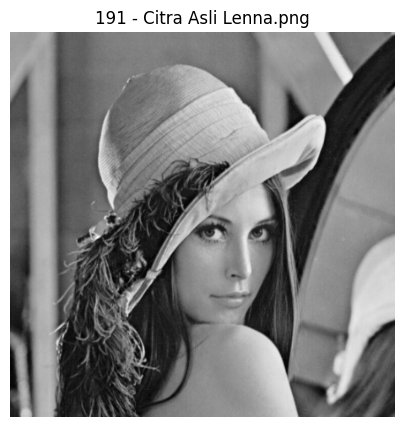

In [49]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread(
    '/content/Lenna.png',
    cv.IMREAD_GRAYSCALE
)

if img is None:
    raise FileNotFoundError('Lenna.png gagal dibaca.')

print('Ukuran gambar:', img.shape)
print('Tipe data:', img.dtype)

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli Lenna.png')
plt.axis('off')
plt.show()

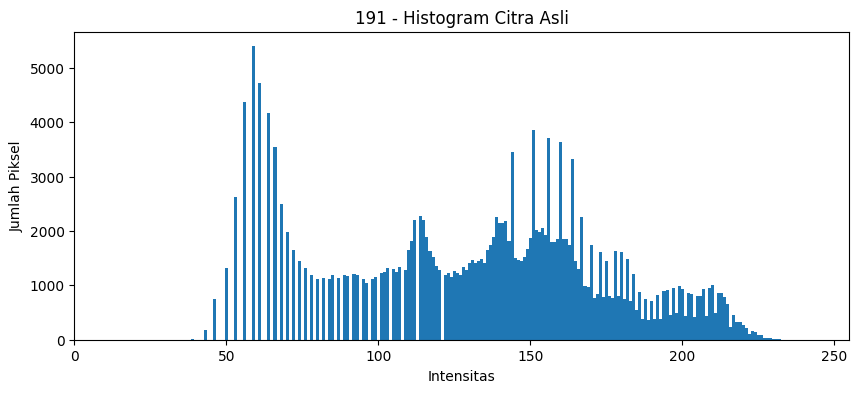

In [50]:
hist = np.bincount(
    img.ravel(),
    minlength=256
)

plt.figure(figsize=(10, 4))
plt.bar(
    np.arange(256),
    hist,
    width=1
)
plt.title(NIM + ' - Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim(0, 255)
plt.show()

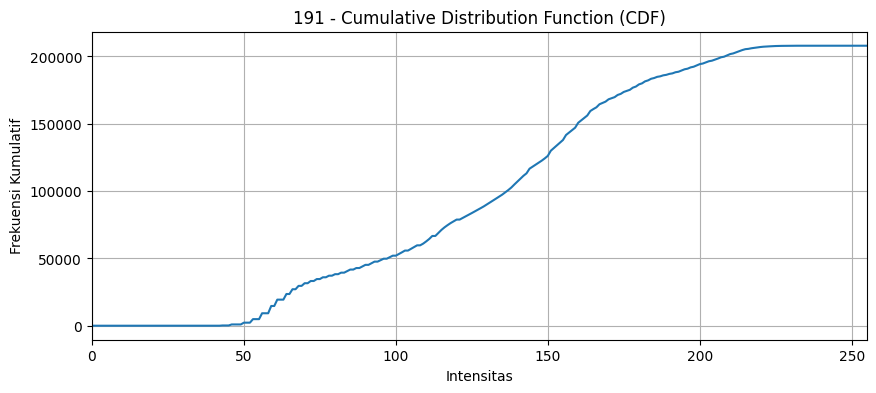

In [51]:
cdf = hist.cumsum()

plt.figure(figsize=(10, 4))
plt.plot(cdf)
plt.title(NIM + ' - Cumulative Distribution Function (CDF)')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi Kumulatif')
plt.xlim(0, 255)
plt.grid()
plt.show()

In [53]:
cdf_min = cdf[cdf > 0].min()
total_pixel = img.size
L = 256

print('CDF minimum :', cdf_min)
print('Jumlah pixel:', total_pixel)
print('Nilai L     :', L)

CDF minimum : 12
Jumlah pixel: 207936
Nilai L     : 256


In [54]:
lut = np.round(
    (cdf - cdf_min) /
    (total_pixel - cdf_min) *
    (L - 1)
)

lut = np.clip(lut, 0, 255).astype(np.uint8)

print('LUT berhasil dibuat.')

LUT berhasil dibuat.


In [55]:
img_he_manual = lut[img]

print('Ukuran citra:', img_he_manual.shape)
print('Tipe data:', img_he_manual.dtype)
print('Rentang intensitas:',
      img_he_manual.min(), '-',
      img_he_manual.max())

Ukuran citra: (456, 456)
Tipe data: uint8
Rentang intensitas: 0 - 255


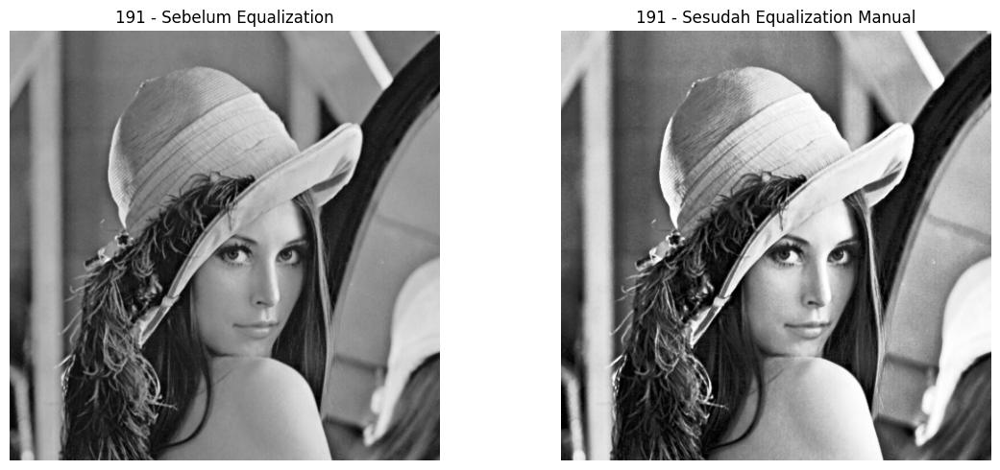

In [56]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Sebelum Equalization')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_he_manual, cmap='gray')
plt.title(NIM + ' - Sesudah Equalization Manual')
plt.axis('off')

plt.tight_layout()
plt.show()

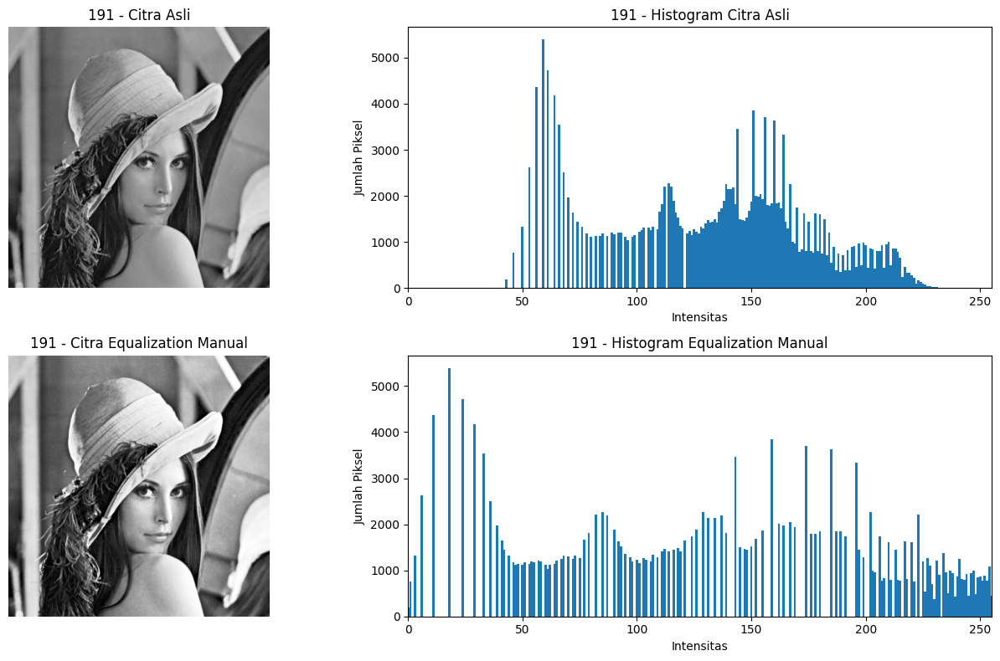

In [57]:
hist_before = np.bincount(img.ravel(), minlength=256)
hist_after = np.bincount(img_he_manual.ravel(), minlength=256)

plt.figure(figsize=(14,8))

# Citra asli
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

# Histogram asli
plt.subplot(2,2,2)
plt.bar(np.arange(256), hist_before, width=1)
plt.title(NIM + ' - Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim(0,255)

# Citra hasil equalization
plt.subplot(2,2,3)
plt.imshow(img_he_manual, cmap='gray')
plt.title(NIM + ' - Citra Equalization Manual')
plt.axis('off')

# Histogram hasil
plt.subplot(2,2,4)
plt.bar(np.arange(256), hist_after, width=1)
plt.title(NIM + ' - Histogram Equalization Manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim(0,255)

plt.tight_layout()
plt.show()

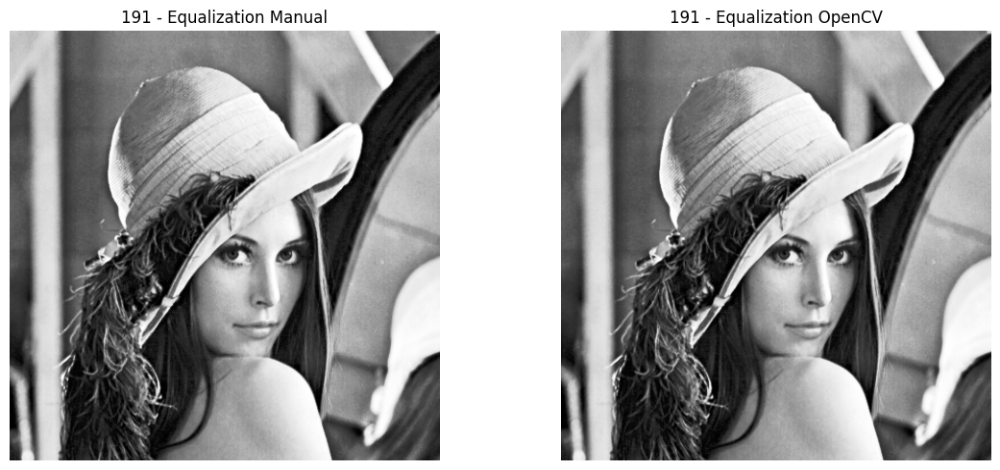

In [58]:
img_he_cv = cv.equalizeHist(img)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_he_manual, cmap='gray')
plt.title(NIM + ' - Equalization Manual')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_he_cv, cmap='gray')
plt.title(NIM + ' - Equalization OpenCV')
plt.axis('off')

plt.tight_layout()
plt.show()

In [59]:
diff = cv.absdiff(img_he_manual, img_he_cv)

print('Selisih maksimum:', diff.max())
print('Jumlah piksel berbeda:', np.count_nonzero(diff))
print('Rata-rata selisih:', diff.mean())

Selisih maksimum: 0
Jumlah piksel berbeda: 0
Rata-rata selisih: 0.0


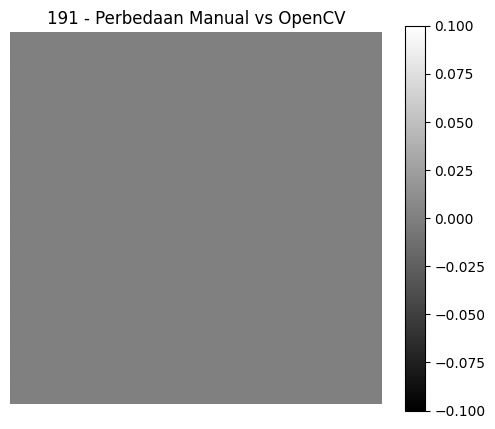

In [60]:
plt.figure(figsize=(6,5))
plt.imshow(diff, cmap='gray')
plt.title(NIM + ' - Perbedaan Manual vs OpenCV')
plt.axis('off')
plt.colorbar()
plt.show()

In [61]:
import os

print(os.listdir('/content'))

['.config', 'Lenna.png', 'drive', 'sample_data']


In [62]:
ktm = cv.imread('/content/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

if ktm is None:
    raise FileNotFoundError('KTM1a.jpg gagal dibaca.')

print('Ukuran KTM:', ktm.shape)
print('Tipe data:', ktm.dtype)

plt.figure(figsize=(6,5))
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - KTM1a.jpg')
plt.axis('off')
plt.show()

FileNotFoundError: KTM1a.jpg gagal dibaca.

In [63]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Kartukeluarga.pdf', 'Ijazah.pdf', 'Akta.pdf', 'IMG-20200815-WA0056.jpg', 'AKTA Kelahiran.pdf', 'Kartu Keluarga.jpg', '0051356722_Akta_Sharren Elvaretta Pratamadya Fianto.pdf', '0051356722_KK_Sharren Elvaretta Pratamadya Fianto.jpg', '0051356722_SKL_Sharren Elvaretta Pratamadya Fianto.pdf', 'photo_2021-09-06_18-21-48.jpg', 'IMG_20211110_175952.jpg', 'IMG_20211110_175928.jpg', 'IMG_20211110_175855.jpg', 'Sertifikat Lomba (2).jpg', 'Sertifikat Lomba (1).jpg', 'Sertifikat Lomba.jpg', 'SERTIFIKAT LOMBA SHARREN 1.pdf', 'SERTIFIKAT LOMBA SHARREN 2.pdf', 'SERTIFIKAT LOMBA SHARREN 3.pdf', 'Screenshot_2022-04-04-17-45-09-351_org.mozilla.firefox.jpg', '1659344683371.jpeg', 'IMG-20221225-WA0036.jpg', 'IMG-20221228-WA0021.jpg', 'IMG-20221223-WA0035.jpg', 'Sma award', 'IMG_2757.MOV', '31811362.pdf', 'BE5B4761-CE5D-482B-8D8A-94A16BA5149A.jpeg', 'EBD76D86-A2D1-4470-9511-E77597CAD252.png', 'D2134D67-935F-43F6-938A-B9C1DBD67393.jpeg', '29_Rifat_Di Ambang Keberhasilan Dan Kegagalan.d

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [65]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower() == 'ktm1a.jpg':
            print(os.path.join(root, file))

/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1a.jpg


In [66]:
ktm = cv.imread('/content/KTM1a.jpg', cv.IMREAD_GRAYSCALE)

In [69]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.lower() == 'ktm1a.jpg':
            print(os.path.join(root, file))

/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1a.jpg


Ukuran gambar: (1024, 1600)
Tipe data: uint8


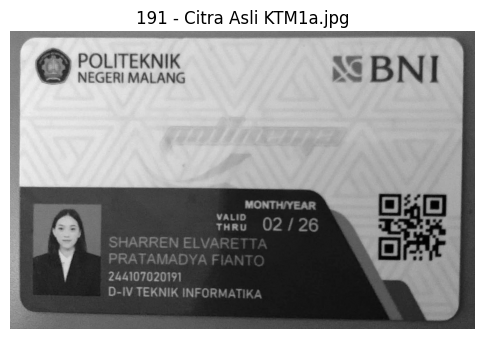

In [71]:
ktm = cv.imread(
    '/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1a.jpg',
    cv.IMREAD_GRAYSCALE
)

if ktm is None:
    raise FileNotFoundError('KTM1a.jpg gagal dibaca.')

print('Ukuran gambar:', ktm.shape)
print('Tipe data:', ktm.dtype)

plt.figure(figsize=(6,5))
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - Citra Asli KTM1a.jpg')
plt.axis('off')
plt.show()

In [72]:
hist_ktm = np.bincount(ktm.ravel(), minlength=256)

cdf_ktm = hist_ktm.cumsum()

cdf_min_ktm = cdf_ktm[cdf_ktm > 0].min()
total_pixel_ktm = ktm.size
L = 256

lut_ktm = np.round(
    (cdf_ktm - cdf_min_ktm) /
    (total_pixel_ktm - cdf_min_ktm) *
    (L - 1)
)

lut_ktm = np.clip(lut_ktm, 0, 255).astype(np.uint8)

ktm_he_manual = lut_ktm[ktm]

print('CDF minimum:', cdf_min_ktm)
print('Jumlah pixel:', total_pixel_ktm)
print('Rentang hasil:',
      ktm_he_manual.min(), '-',
      ktm_he_manual.max())

CDF minimum: 1023
Jumlah pixel: 1638400
Rentang hasil: 0 - 255


In [73]:
ktm_he_cv = cv.equalizeHist(ktm)

print('Rentang hasil OpenCV:',
      ktm_he_cv.min(), '-',
      ktm_he_cv.max())

Rentang hasil OpenCV: 0 - 255


In [74]:
diff_ktm = cv.absdiff(ktm_he_manual, ktm_he_cv)

print('Selisih maksimum:', diff_ktm.max())
print('Jumlah piksel berbeda:', np.count_nonzero(diff_ktm))
print('Rata-rata selisih:', diff_ktm.mean())

Selisih maksimum: 0
Jumlah piksel berbeda: 0
Rata-rata selisih: 0.0


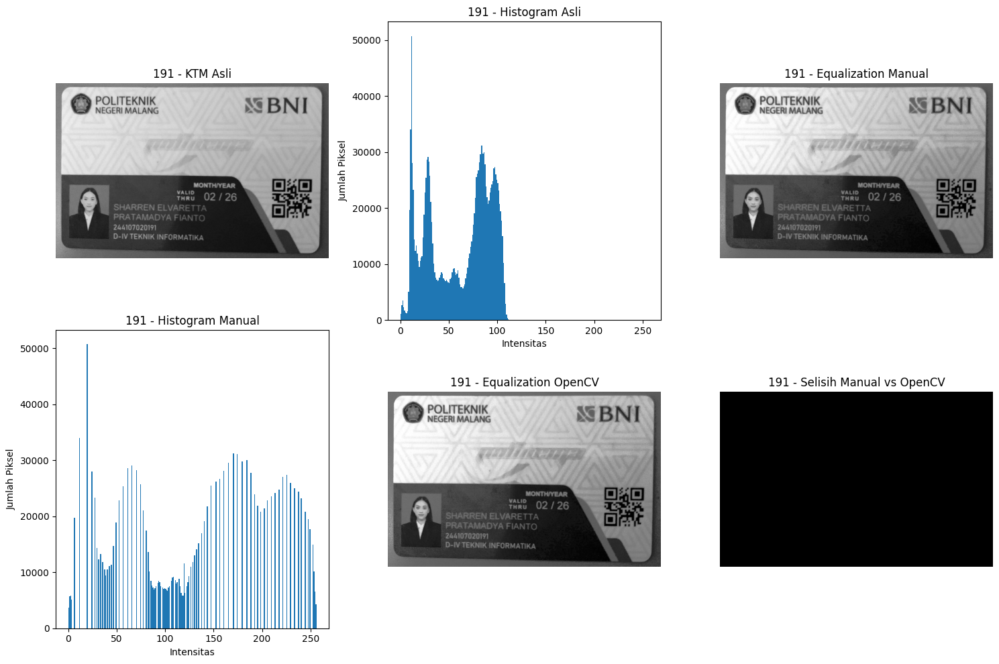

In [75]:
plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - KTM Asli')
plt.axis('off')

plt.subplot(2,3,2)
plt.hist(ktm.ravel(), bins=256, range=(0,256))
plt.title(NIM + ' - Histogram Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(2,3,3)
plt.imshow(ktm_he_manual, cmap='gray')
plt.title(NIM + ' - Equalization Manual')
plt.axis('off')

plt.subplot(2,3,4)
plt.hist(ktm_he_manual.ravel(), bins=256, range=(0,256))
plt.title(NIM + ' - Histogram Manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')

plt.subplot(2,3,5)
plt.imshow(ktm_he_cv, cmap='gray')
plt.title(NIM + ' - Equalization OpenCV')
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(diff_ktm, cmap='gray')
plt.title(NIM + ' - Selisih Manual vs OpenCV')
plt.axis('off')

plt.tight_layout()
plt.show()

E-2.3 — Equalization per Channel B, G, R

In [76]:
# Membaca Lenna dalam format warna BGR
lenna_color = cv.imread('/content/Lenna.png')

if lenna_color is None:
    raise FileNotFoundError('Lenna.png gagal dibaca.')

print('Ukuran gambar:', lenna_color.shape)
print('Tipe data:', lenna_color.dtype)

Ukuran gambar: (456, 456, 3)
Tipe data: uint8


In [77]:
# Memisahkan channel B, G, dan R
B, G, R = cv.split(lenna_color)

# Equalization masing-masing channel
B_eq = cv.equalizeHist(B)
G_eq = cv.equalizeHist(G)
R_eq = cv.equalizeHist(R)

# Menggabungkan kembali channel
lenna_eq_bgr = cv.merge([B_eq, G_eq, R_eq])

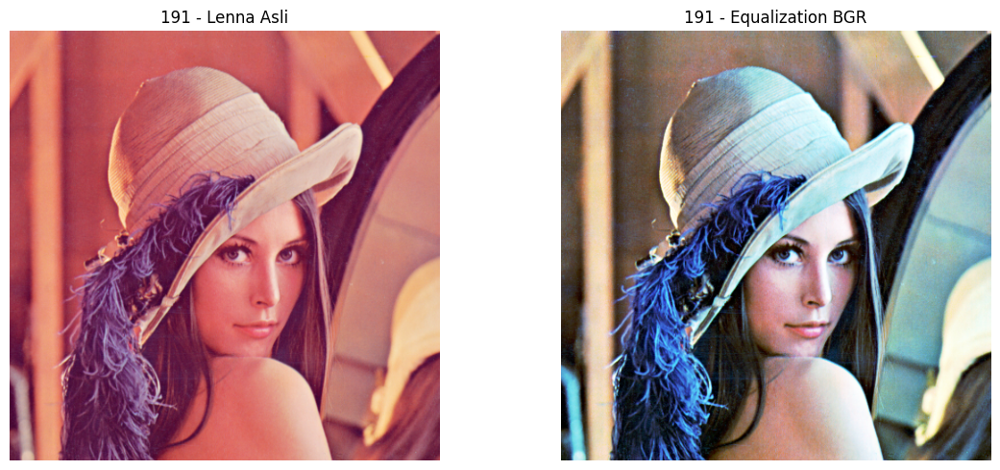

In [78]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(lenna_color, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Lenna Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(lenna_eq_bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization BGR')
plt.axis('off')

plt.tight_layout()
plt.show()

In [79]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower() == 'ktm1d.jpg':
            print(os.path.join(root, file))

/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1d.jpg


In [80]:
ktm_color = cv.imread(
    '/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1d.jpg'
)

if ktm_color is None:
    raise FileNotFoundError('KTM1d.jpg gagal dibaca.')

B, G, R = cv.split(ktm_color)

B_eq = cv.equalizeHist(B)
G_eq = cv.equalizeHist(G)
R_eq = cv.equalizeHist(R)

ktm_eq_bgr = cv.merge([B_eq, G_eq, R_eq])

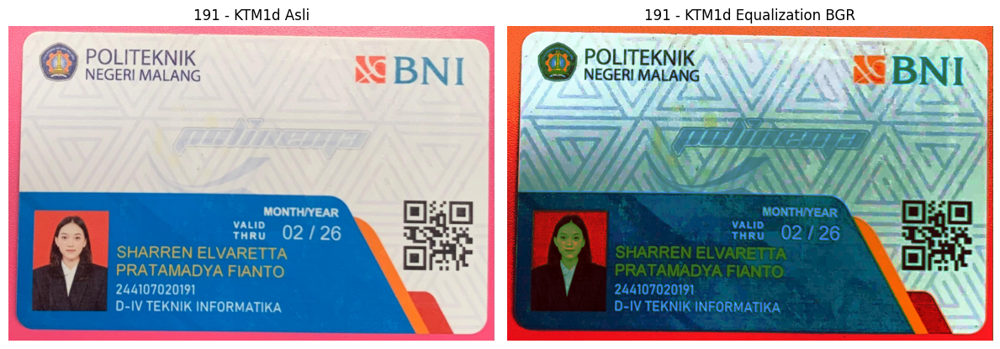

In [81]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cv.cvtColor(ktm_color, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1d Asli')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cv.cvtColor(ktm_eq_bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - KTM1d Equalization BGR')
plt.axis('off')

plt.tight_layout()
plt.show()

In [82]:
# Membaca citra warna
img_color = cv.imread('/content/Lenna.png')

if img_color is None:
    raise FileNotFoundError('Lenna.png gagal dibaca.')

# Konversi ke RGB untuk ditampilkan
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

In [83]:
B, G, R = cv.split(img_color)

B_eq = cv.equalizeHist(B)
G_eq = cv.equalizeHist(G)
R_eq = cv.equalizeHist(R)

img_bgr_eq = cv.merge([B_eq, G_eq, R_eq])

In [84]:
# Konversi BGR ke YCrCb
img_ycrcb = cv.cvtColor(img_color, cv.COLOR_BGR2YCrCb)

# Pisahkan channel
Y, Cr, Cb = cv.split(img_ycrcb)

# Equalization hanya pada Y
Y_eq = cv.equalizeHist(Y)

# Gabungkan kembali
img_ycrcb_eq = cv.merge([Y_eq, Cr, Cb])

# Kembali ke BGR
img_y_eq = cv.cvtColor(img_ycrcb_eq, cv.COLOR_YCrCb2BGR)

In [85]:
# Konversi BGR ke HSV
img_hsv = cv.cvtColor(img_color, cv.COLOR_BGR2HSV)

# Pisahkan channel
H, S, V = cv.split(img_hsv)

# Equalization hanya pada V
V_eq = cv.equalizeHist(V)

# Gabungkan kembali
img_hsv_eq = cv.merge([H, S, V_eq])

# Kembali ke BGR
img_v_eq = cv.cvtColor(img_hsv_eq, cv.COLOR_HSV2BGR)

In [86]:
# Konversi BGR ke LAB
img_lab = cv.cvtColor(img_color, cv.COLOR_BGR2LAB)

# Pisahkan channel
L, A, B_lab = cv.split(img_lab)

# Equalization hanya pada L
L_eq = cv.equalizeHist(L)

# Gabungkan kembali
img_lab_eq = cv.merge([L_eq, A, B_lab])

# Kembali ke BGR
img_l_eq = cv.cvtColor(img_lab_eq, cv.COLOR_LAB2BGR)

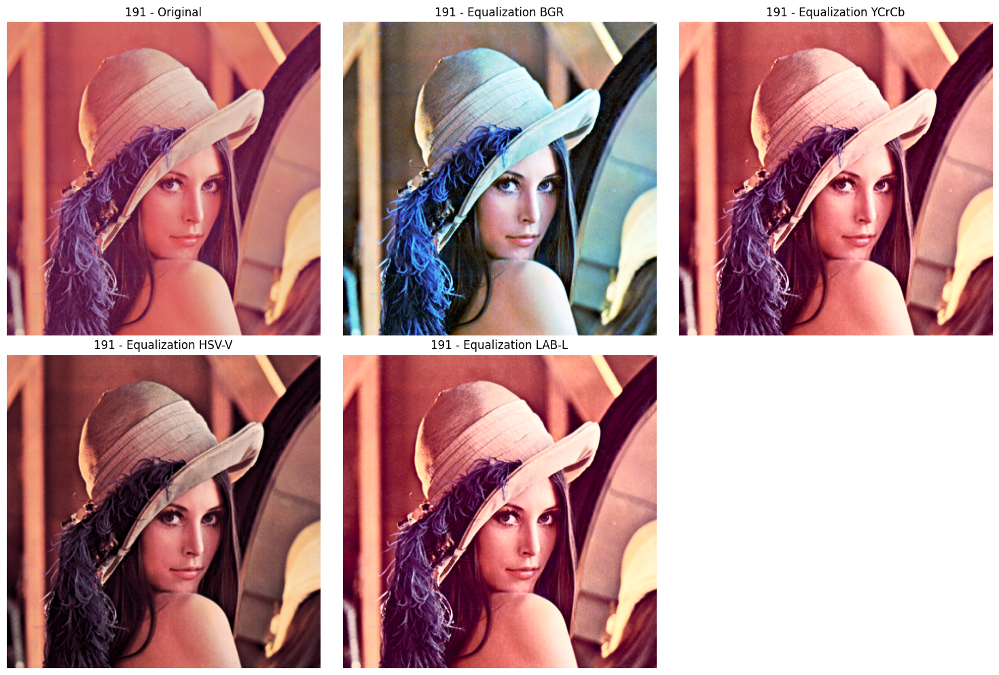

In [87]:
plt.figure(figsize=(15,10))

# Original
plt.subplot(2,3,1)
plt.imshow(img_rgb)
plt.title(NIM + ' - Original')
plt.axis('off')

# BGR
plt.subplot(2,3,2)
plt.imshow(cv.cvtColor(img_bgr_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization BGR')
plt.axis('off')

# YCrCb
plt.subplot(2,3,3)
plt.imshow(cv.cvtColor(img_y_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization YCrCb')
plt.axis('off')

# HSV
plt.subplot(2,3,4)
plt.imshow(cv.cvtColor(img_v_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization HSV-V')
plt.axis('off')

# LAB
plt.subplot(2,3,5)
plt.imshow(cv.cvtColor(img_l_eq, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Equalization LAB-L')
plt.axis('off')

plt.tight_layout()
plt.show()

In [88]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)

    d = np.abs(h1 - h2)

    # Karena Hue OpenCV berada pada 0-179,
    # gunakan jarak melingkar
    d = np.minimum(d, 180 - d)

    return d.mean()

In [89]:
hue_bgr = geser_hue(img_color, img_bgr_eq)
hue_ycrcb = geser_hue(img_color, img_y_eq)
hue_hsv = geser_hue(img_color, img_v_eq)
hue_lab = geser_hue(img_color, img_l_eq)

print('Hue Shift BGR   :', hue_bgr)
print('Hue Shift YCrCb :', hue_ycrcb)
print('Hue Shift HSV-V :', hue_hsv)
print('Hue Shift LAB-L :', hue_lab)

Hue Shift BGR   : 37.62827504616805
Hue Shift YCrCb : 1.0117439981532779
Hue Shift HSV-V : 0.3299765312403817
Hue Shift LAB-L : 1.294566597414589


In [90]:
brightness_original = cv.cvtColor(img_color, cv.COLOR_BGR2GRAY).mean()
brightness_bgr = cv.cvtColor(img_bgr_eq, cv.COLOR_BGR2GRAY).mean()
brightness_ycrcb = cv.cvtColor(img_y_eq, cv.COLOR_BGR2GRAY).mean()
brightness_hsv = cv.cvtColor(img_v_eq, cv.COLOR_BGR2GRAY).mean()
brightness_lab = cv.cvtColor(img_l_eq, cv.COLOR_BGR2GRAY).mean()

print('Mean Brightness Original :', brightness_original)
print('Mean Brightness BGR      :', brightness_bgr)
print('Mean Brightness YCrCb    :', brightness_ycrcb)
print('Mean Brightness HSV-V    :', brightness_hsv)
print('Mean Brightness LAB-L    :', brightness_lab)

Mean Brightness Original : 124.08382386888273
Mean Brightness BGR      : 128.41116016466606
Mean Brightness YCrCb    : 127.98263888888889
Mean Brightness HSV-V    : 91.24445021545091
Mean Brightness LAB-L    : 121.64580447830102


In [91]:
import pandas as pd

hasil_perbandingan = pd.DataFrame({
    'Metode': [
        'BGR',
        'YCrCb - Y',
        'HSV - V',
        'LAB - L'
    ],
    'Hue Shift': [
        hue_bgr,
        hue_ycrcb,
        hue_hsv,
        hue_lab
    ],
    'Mean Brightness': [
        brightness_bgr,
        brightness_ycrcb,
        brightness_hsv,
        brightness_lab
    ]
})

hasil_perbandingan

,Metode,Hue Shift,Mean Brightness
0,BGR,37.628275,128.411160
1,YCrCb - Y,1.011744,127.982639
2,HSV - V,0.329977,91.244450
3,LAB - L,1.294567,121.645804


In [92]:
print(PARAM)

{'bins': 64}


In [93]:
PARAM['clip'] = 1.5
PARAM['tile'] = 5

print(PARAM)

{'bins': 64, 'clip': 1.5, 'tile': 5}


In [94]:
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

img_clahe = clahe.apply(ktm)

print('CLAHE berhasil diterapkan.')
print('Clip Limit:', PARAM['clip'])
print('Tile Grid Size:', PARAM['tile'])

CLAHE berhasil diterapkan.
Clip Limit: 1.5
Tile Grid Size: 5


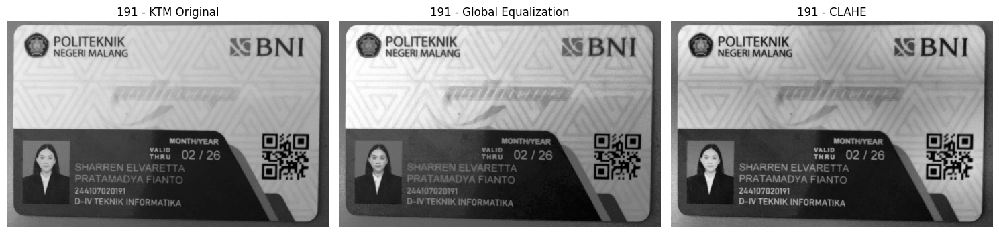

In [95]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - KTM Original')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(ktm_he_cv, cmap='gray')
plt.title(NIM + ' - Global Equalization')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_clahe, cmap='gray')
plt.title(NIM + ' - CLAHE')
plt.axis('off')

plt.tight_layout()
plt.show()

In [96]:
clip_values = [1.0, 1.5, 2.0]

hasil_clahe = []

for clip in clip_values:
    clahe_test = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    hasil = clahe_test.apply(ktm)
    hasil_clahe.append(hasil)

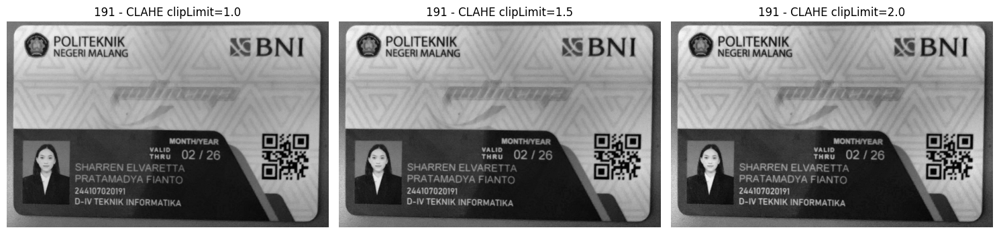

In [97]:
plt.figure(figsize=(15,5))

for i in range(3):
    plt.subplot(1,3,i+1)
    plt.imshow(hasil_clahe[i], cmap='gray')
    plt.title(
        NIM + ' - CLAHE clipLimit=' + str(clip_values[i])
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

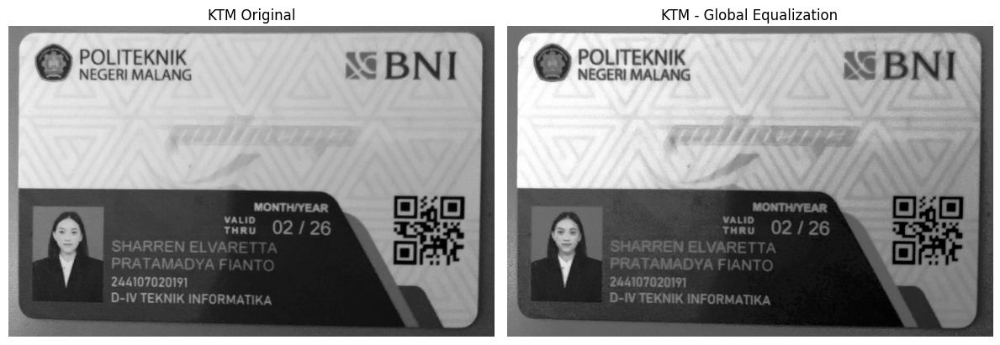

In [98]:
# Global Histogram Equalization
ktm_equalized = cv.equalizeHist(ktm)

# Tampilkan hasil
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ktm, cmap='gray')
plt.title('KTM Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ktm_equalized, cmap='gray')
plt.title('KTM - Global Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

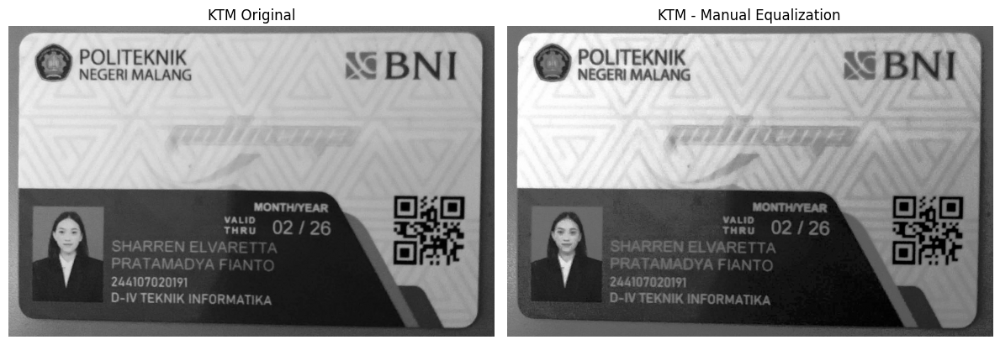

In [99]:
hist = np.bincount(ktm.ravel(), minlength=256)
cdf = hist.cumsum()

cdf_min = cdf[cdf > 0].min()
total_pixel = ktm.size
L = 256

lut = np.round(
    (cdf - cdf_min) /
    (total_pixel - cdf_min) *
    (L - 1)
)

lut = np.clip(lut, 0, 255).astype(np.uint8)

ktm_manual = lut[ktm]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ktm, cmap='gray')
plt.title('KTM Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ktm_manual, cmap='gray')
plt.title('KTM - Manual Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

ktm_manual → histogram equalization manual

ktm_equalized → cv.equalizeHist()

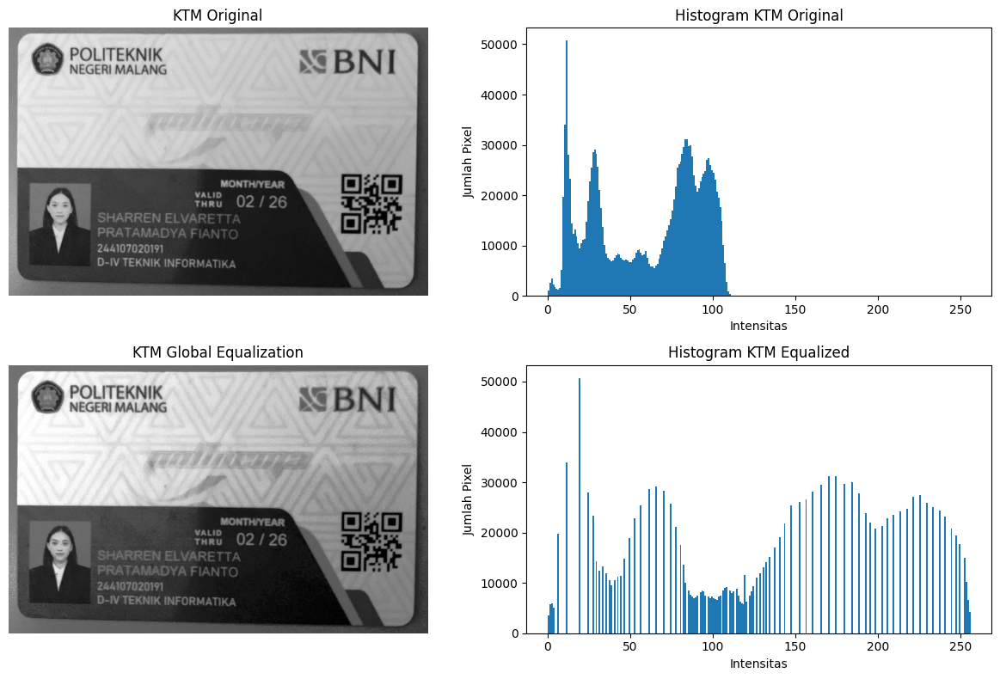

In [100]:
plt.figure(figsize=(12, 8))

# Original
plt.subplot(2, 2, 1)
plt.imshow(ktm, cmap='gray')
plt.title('KTM Original')
plt.axis('off')

# Histogram original
plt.subplot(2, 2, 2)
plt.hist(ktm.ravel(), bins=256, range=(0, 256))
plt.title('Histogram KTM Original')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# Equalized
plt.subplot(2, 2, 3)
plt.imshow(ktm_equalized, cmap='gray')
plt.title('KTM Global Equalization')
plt.axis('off')

# Histogram equalized
plt.subplot(2, 2, 4)
plt.hist(ktm_equalized.ravel(), bins=256, range=(0, 256))
plt.title('Histogram KTM Equalized')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

KTM Original
→ histogram biasanya terkonsentrasi pada rentang intensitas tertentu karena kondisi pencahayaan.

KTM Equalized
→ distribusi intensitas menjadi lebih tersebar sehingga kontras gambar meni

In [102]:
# Hitung MSE
mse = np.mean(
    (ktm.astype(np.float64) - ktm_equalized.astype(np.float64)) ** 2
)

# Hitung PSNR
if mse == 0:
    psnr = float('inf')
else:
    psnr = 10 * np.log10((255 ** 2) / mse)

print("MSE  :", mse)
print("PSNR :", psnr, "dB")

MSE  : 6528.953692016602
PSNR : 9.982367725778872 dB


Nilai PSNR antara citra KTM original dan citra hasil global histogram equalization dihitung berdasarkan perbedaan nilai piksel kedua citra. Hasil equalization mengubah nilai intensitas piksel agar distribusi intensitas menjadi lebih merata sehingga kontras citra meningkat.

PSNR dapat mengalami penurunan meskipun citra hasil equalization terlihat lebih jelas. Hal ini terjadi karena PSNR mengukur kemiripan nilai piksel antara citra original dan citra hasil, bukan tingkat keterbacaan informasi pada citra. Semakin besar perubahan nilai piksel, semakin besar pula MSE dan semakin rendah nilai PSNR.

Dengan demikian, PSNR kurang tepat jika digunakan sebagai satu-satunya ukuran untuk menilai keterbacaan NIM atau nama pada KTM. Untuk menilai keterbacaan, diperlukan ukuran yang berkaitan dengan kontras, kualitas teks, atau keberhasilan pembacaan karakter, misalnya menggunakan OCR atau metrik kontras yang sesuai.


In [103]:
# Membuat CLAHE
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

# Terapkan CLAHE pada KTM grayscale
ktm_clahe = clahe.apply(ktm)

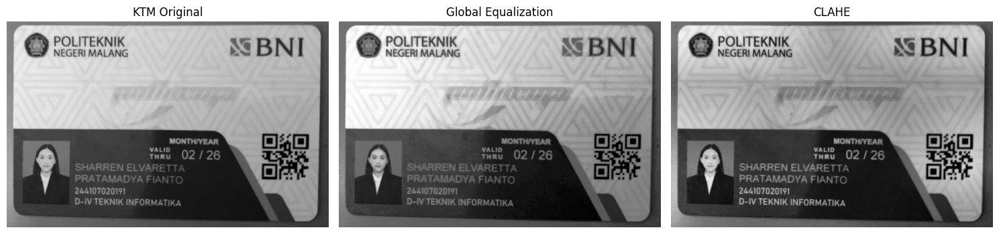

In [104]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ktm, cmap='gray')
plt.title('KTM Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(ktm_equalized, cmap='gray')
plt.title('Global Equalization')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(ktm_clahe, cmap='gray')
plt.title('CLAHE')
plt.axis('off')

plt.tight_layout()
plt.show()

Global Histogram Equalization dan CLAHE sama-sama digunakan untuk meningkatkan kontras citra, tetapi cara kerjanya berbeda. Global Histogram Equalization melakukan pemerataan histogram berdasarkan keseluruhan citra, sedangkan CLAHE melakukan pemerataan histogram secara lokal pada beberapa area kecil (*tiles*) dan membatasi peningkatan kontras menggunakan nilai *clipLimit*.

Pada citra KTM, perbandingan dilakukan dengan memperhatikan keterbacaan NIM dan nama serta tingkat noise pada citra. Metode yang menghasilkan tulisan lebih jelas dengan noise yang masih terkendali dapat dipilih sebagai metode yang lebih sesuai untuk citra tersebut. Hasil pengamatan dilakukan berdasarkan citra hasil percobaan, karena efektivitas CLAHE dapat dipengaruhi oleh kondisi pencahayaan dan karakteristik citra KTM.


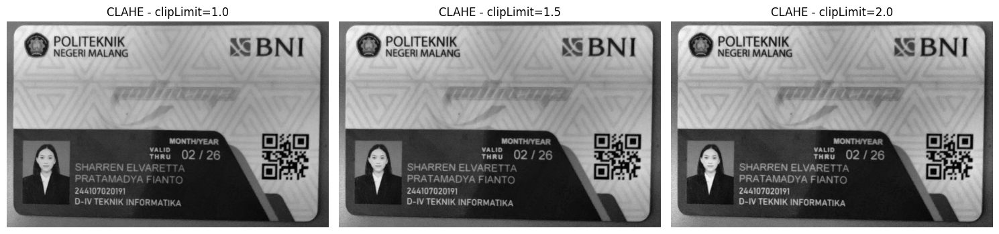

In [105]:
clip_values = [1.0, 1.5, 2.0]

plt.figure(figsize=(15, 5))

for i, clip in enumerate(clip_values):
    clahe_test = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    result = clahe_test.apply(ktm)

    plt.subplot(1, 3, i + 1)
    plt.imshow(result, cmap='gray')
    plt.title(f'CLAHE - clipLimit={clip}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Percobaan dilakukan dengan tiga nilai *clipLimit*, yaitu 1,0; 1,5; dan 2,0. Perubahan nilai *clipLimit* memengaruhi tingkat peningkatan kontras lokal pada citra.

Semakin besar nilai *clipLimit*, peningkatan kontras lokal menjadi semakin kuat. Hal tersebut dapat membantu memperjelas detail pada area tertentu, tetapi sekaligus dapat menyebabkan noise pada citra menjadi semakin terlihat.

Nilai *clipLimit* yang digunakan sebagai hasil pilihan sebaiknya ditentukan berdasarkan keseimbangan antara keterbacaan NIM dan nama dengan tingkat noise. Nilai yang menghasilkan tulisan paling jelas dengan noise yang masih terkendali merupakan pilihan yang paling sesuai untuk citra KTM pada percobaan ini.

Area yang perlu diamati ketika *clipLimit* dinaikkan adalah bagian background atau area KTM yang memiliki tekstur/noise. Pada area tersebut, peningkatan kontras yang terlalu kuat dapat membuat noise menjadi lebih menonjol.


Tugas

In [106]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [107]:
print(PARAM)

{'bins': 64, 'clip': 1.5, 'tile': 5}


In [108]:
def floyd_steinberg(img, L):
    img = img.astype(np.float64).copy()

    h, w = img.shape

    # Jarak antar level kuantisasi
    step = 255 / (L - 1)

    for y in range(h):
        for x in range(w):

            old_pixel = img[y, x]

            # Kuantisasi ke level terdekat
            new_pixel = np.round(old_pixel / step) * step

            # Pastikan berada pada rentang 0-255
            new_pixel = np.clip(new_pixel, 0, 255)

            img[y, x] = new_pixel

            # Hitung error
            error = old_pixel - new_pixel

            # Sebarkan error sesuai Floyd-Steinberg
            if x + 1 < w:
                img[y, x + 1] += error * 7 / 16

            if y + 1 < h and x - 1 >= 0:
                img[y + 1, x - 1] += error * 3 / 16

            if y + 1 < h:
                img[y + 1, x] += error * 5 / 16

            if y + 1 < h and x + 1 < w:
                img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

In [110]:
lena = cv.imread('/content/Lenna.png', cv.IMREAD_GRAYSCALE)

print(lena.shape)
print(lena.dtype)

(456, 456)
uint8


In [112]:
print(PARAM)

{'bins': 64, 'clip': 1.5, 'tile': 5}


In [113]:
L_test = 2

lena_dither = floyd_steinberg(
    lena,
    L_test
)

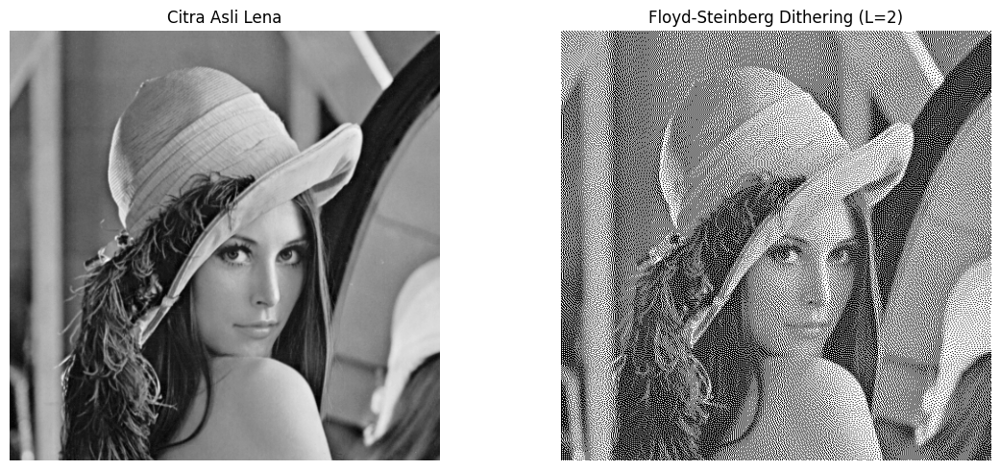

In [114]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(lena, cmap='gray')
plt.title('Citra Asli Lena')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lena_dither, cmap='gray')
plt.title(f'Floyd-Steinberg Dithering (L={L_test})')
plt.axis('off')

plt.tight_layout()
plt.show()

In [115]:
levels = np.unique(lena_dither)

print("Level intensitas:", levels)
print("Jumlah level:", len(levels))

Level intensitas: [  0 255]
Jumlah level: 2


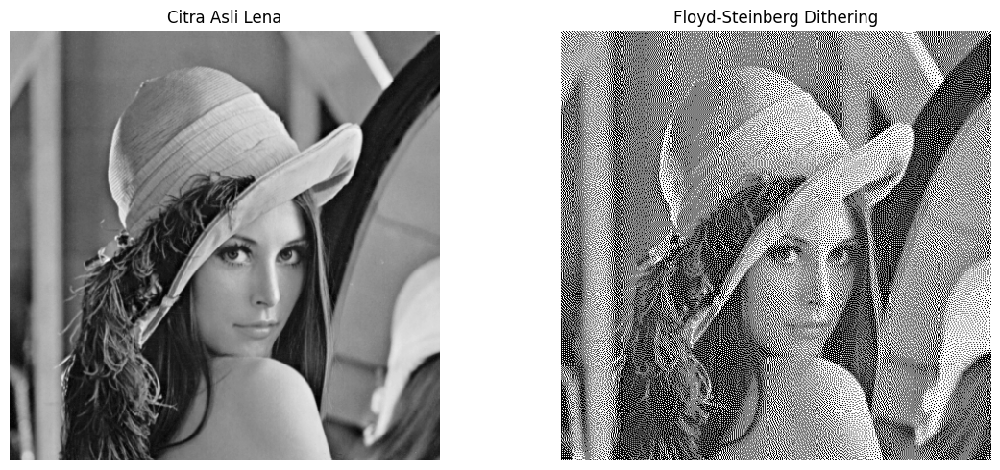

In [116]:
L = 2

lena_dither = floyd_steinberg(lena, L)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(lena, cmap='gray')
plt.title('Citra Asli Lena')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lena_dither, cmap='gray')
plt.title('Floyd-Steinberg Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

In [117]:
levels = np.unique(lena_dither)

print("Level intensitas:", levels)
print("Jumlah level:", len(levels))

Level intensitas: [  0 255]
Jumlah level: 2


In [118]:
ktm1b_path = '/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1b.jpg'

ktm1b = cv.imread(ktm1b_path, cv.IMREAD_GRAYSCALE)

print(ktm1b.shape)
print(ktm1b.dtype)

(1014, 1600)
uint8


In [119]:
ktm1b_dither = floyd_steinberg(
    ktm1b,
    L
)

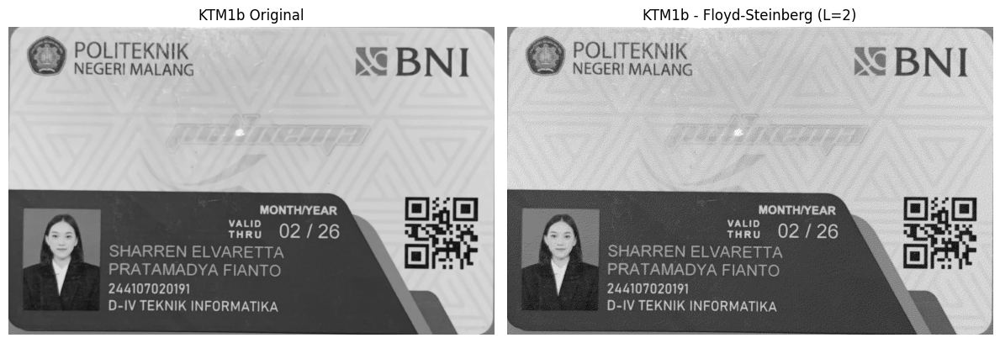

In [120]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ktm1b, cmap='gray')
plt.title('KTM1b Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ktm1b_dither, cmap='gray')
plt.title(f'KTM1b - Floyd-Steinberg (L={L})')
plt.axis('off')

plt.tight_layout()
plt.show()

In [121]:
levels_ktm = np.unique(ktm1b_dither)

print("Level intensitas:", levels_ktm)
print("Jumlah level:", len(levels_ktm))

Level intensitas: [  0 255]
Jumlah level: 2


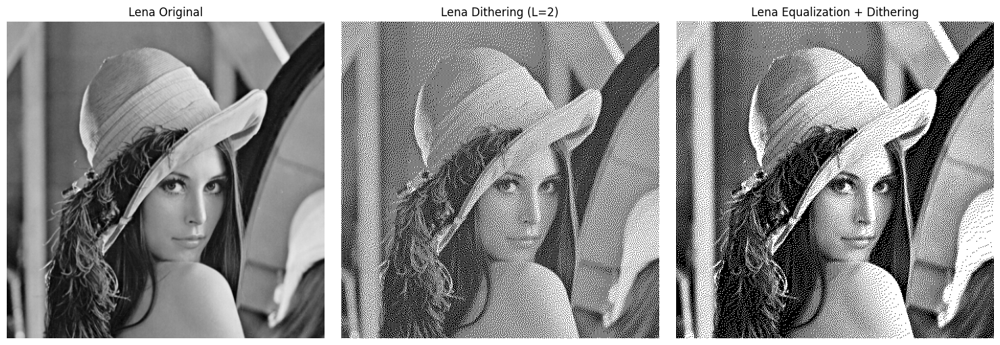

Level Lena dithering: [  0 255]
Jumlah level: 2


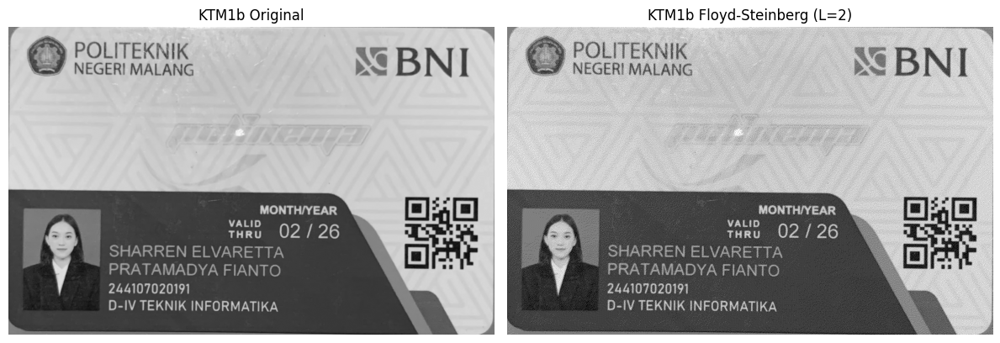

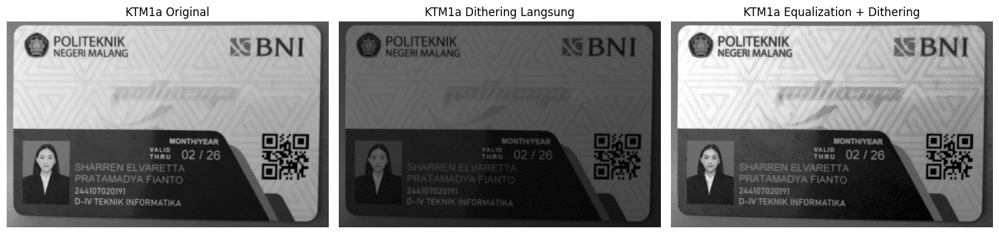

Level KTM dithering: [  0 255]
Level KTM EQ + dithering: [  0 255]


In [122]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# PARAMETER
# ============================================================
L = 2

# ============================================================
# FUNGSI FLOYD-STEINBERG
# ============================================================
def floyd_steinberg(img, L):
    img = img.astype(np.float64).copy()
    h, w = img.shape
    step = 255 / (L - 1)

    for y in range(h):
        for x in range(w):
            old_pixel = img[y, x]

            new_pixel = np.round(old_pixel / step) * step
            new_pixel = np.clip(new_pixel, 0, 255)

            img[y, x] = new_pixel
            error = old_pixel - new_pixel

            if x + 1 < w:
                img[y, x + 1] += error * 7 / 16

            if y + 1 < h and x - 1 >= 0:
                img[y + 1, x - 1] += error * 3 / 16

            if y + 1 < h:
                img[y + 1, x] += error * 5 / 16

            if y + 1 < h and x + 1 < w:
                img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)


# ============================================================
# 1. LENA
# ============================================================
lena = cv.imread('/content/Lenna.png', cv.IMREAD_GRAYSCALE)

# Dithering langsung
lena_dither = floyd_steinberg(lena, L)

# Equalization kemudian dithering
lena_equalized = cv.equalizeHist(lena)
lena_eq_dither = floyd_steinberg(lena_equalized, L)

# Tampilkan Lena
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(lena, cmap='gray')
plt.title('Lena Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(lena_dither, cmap='gray')
plt.title(f'Lena Dithering (L={L})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(lena_eq_dither, cmap='gray')
plt.title(f'Lena Equalization + Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Level Lena dithering:", np.unique(lena_dither))
print("Jumlah level:", len(np.unique(lena_dither)))


# ============================================================
# 2. KTM1b - DITHERING
# ============================================================
ktm1b_path = '/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1b.jpg'
ktm1b = cv.imread(ktm1b_path, cv.IMREAD_GRAYSCALE)

ktm1b_dither = floyd_steinberg(ktm1b, L)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ktm1b, cmap='gray')
plt.title('KTM1b Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ktm1b_dither, cmap='gray')
plt.title(f'KTM1b Floyd-Steinberg (L={L})')
plt.axis('off')

plt.tight_layout()
plt.show()


# ============================================================
# 3. KTM1a - DITHERING LANGSUNG vs EQUALIZATION + DITHERING
# ============================================================
ktm1a_path = '/content/drive/MyDrive/PCVK IMAGES/244107020191/KTM1a.jpg'
ktm = cv.imread(ktm1a_path, cv.IMREAD_GRAYSCALE)

# Dithering langsung
ktm_dither = floyd_steinberg(ktm, L)

# Equalization
ktm_equalized = cv.equalizeHist(ktm)

# Equalization + dithering
ktm_eq_dither = floyd_steinberg(ktm_equalized, L)

# Tampilkan hasil akhir KTM
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ktm, cmap='gray')
plt.title('KTM1a Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(ktm_dither, cmap='gray')
plt.title('KTM1a Dithering Langsung')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(ktm_eq_dither, cmap='gray')
plt.title('KTM1a Equalization + Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Level KTM dithering:", np.unique(ktm_dither))
print("Level KTM EQ + dithering:", np.unique(ktm_eq_dither))

Pada percobaan ini dilakukan dua urutan pengolahan citra pada KTM1a.jpg. Percobaan pertama menerapkan Floyd–Steinberg dithering secara langsung setelah citra diubah menjadi grayscale. Percobaan kedua menerapkan histogram equalization terlebih dahulu, kemudian hasilnya diproses menggunakan Floyd–Steinberg dithering.

Urutan pertama adalah:

KTM grayscale → Floyd–Steinberg dithering

Sedangkan urutan kedua adalah:

KTM grayscale → Histogram Equalization → Floyd–Steinberg dithering

Histogram equalization dilakukan terlebih dahulu untuk memperbaiki distribusi intensitas dan meningkatkan kontras citra. Setelah itu, dithering digunakan untuk menghasilkan citra dengan jumlah level intensitas yang lebih terbatas sekaligus mempertahankan persepsi detail melalui penyebaran error ke piksel tetangga.

Berdasarkan hasil pengamatan pada citra KTM, perbandingan difokuskan pada keterbacaan NIM dan nama. Hasil yang memiliki kontras tulisan lebih jelas dan detail teks yang lebih mudah dibedakan dari background dapat dianggap memiliki keterbacaan yang lebih baik. Pengamatan juga perlu memperhatikan munculnya noise karena peningkatan kontras sebelum proses dithering dapat membuat detail maupun noise tertentu menjadi lebih terlihat.

Dengan demikian, urutan pengolahan tidak hanya dibandingkan berdasarkan perubahan visual keseluruhan citra, tetapi terutama berdasarkan kemampuan hasil akhir dalam mempertahankan dan menampilkan informasi teks pada KTM.


# E-3 TUGAS PRAKTIKUM DITHERING

## 1. Floyd–Steinberg Dithering

### a. Tahap 1 — Citra Lena

Pada tahap pertama, citra Lena diubah menjadi grayscale kemudian diproses menggunakan metode Floyd–Steinberg dithering. Proses dithering dilakukan dengan membatasi jumlah level intensitas sesuai parameter `L`.

Algoritma Floyd–Steinberg bekerja dengan melakukan kuantisasi terhadap nilai piksel dan menghitung error antara nilai piksel sebelum dan sesudah kuantisasi. Error tersebut kemudian didistribusikan kepada piksel tetangga menggunakan bobot:

* kanan: 7/16
* kiri bawah: 3/16
* bawah: 5/16
* kanan bawah: 1/16

Hasil dithering menghasilkan citra dengan jumlah level intensitas yang lebih terbatas, tetapi tetap mempertahankan persepsi detail melalui penyebaran error.

**Hasil pengamatan:**
Citra setelah dithering memiliki tampilan berupa pola titik atau variasi piksel yang digunakan untuk mempertahankan informasi tingkat keabuan meskipun jumlah level intensitas telah dikurangi.

**Gambar:**
Masukkan screenshot hasil `Lena Original` dan `Lena Dithering`.

---

### b. Tahap 2 — Citra KTM1b

Proses yang sama kemudian diterapkan pada citra `KTM1b.jpg`.

Citra KTM diubah menjadi grayscale dan diproses menggunakan Floyd–Steinberg dengan jumlah level intensitas `L` yang digunakan pada percobaan.

**Hasil pengamatan:**
Dithering menghasilkan citra dengan jumlah tingkat intensitas yang lebih terbatas. Detail citra tetap dapat dikenali karena error kuantisasi disebarkan ke piksel di sekitarnya.

**Gambar:**
Masukkan screenshot hasil `KTM1b Original` dan `KTM1b Floyd-Steinberg`.

---

# 2. Histogram Equalization kemudian Floyd–Steinberg Dithering

Pada percobaan kedua dilakukan dua urutan pengolahan citra untuk mengetahui pengaruh histogram equalization terhadap hasil dithering.

### Urutan pertama

**Grayscale → Floyd–Steinberg Dithering**

### Urutan kedua

**Grayscale → Histogram Equalization → Floyd–Steinberg Dithering**

Histogram equalization digunakan terlebih dahulu untuk memperbaiki distribusi intensitas dan meningkatkan kontras citra. Selanjutnya, hasil equalization diproses menggunakan Floyd–Steinberg dithering.

---

## a. Percobaan pada Lena

Pada citra Lena dilakukan histogram equalization menggunakan `cv.equalizeHist()`, kemudian hasilnya diproses menggunakan Floyd–Steinberg dithering.

Hasil tersebut dibandingkan dengan citra yang langsung diproses menggunakan Floyd–Steinberg tanpa histogram equalization.

**Hasil pengamatan:**
Histogram equalization mengubah distribusi intensitas sebelum proses dithering. Akibatnya, pola dithering pada citra hasil dapat berbeda dibandingkan dengan dithering yang dilakukan langsung pada citra original.

**Gambar:**
Masukkan screenshot:

1. Lena Original
2. Lena Dithering
3. Lena Equalization + Dithering

---

## b. Percobaan pada KTM1a

Pada KTM1a dilakukan dua metode pengolahan:

**Metode 1:**

KTM grayscale → Floyd–Steinberg

**Metode 2:**

KTM grayscale → Histogram Equalization → Floyd–Steinberg

Hasil kedua metode dibandingkan terutama pada bagian **NIM, nama, dan tulisan kecil pada KTM**.

### Hasil pengamatan

Dithering langsung mempertahankan distribusi intensitas awal citra. Apabila citra memiliki kontras yang rendah, tulisan tertentu dapat kurang terlihat setelah proses dithering.

Pada metode histogram equalization yang dilanjutkan dengan dithering, distribusi intensitas diperbaiki terlebih dahulu sehingga perbedaan antara area terang dan gelap dapat menjadi lebih jelas sebelum dilakukan kuantisasi.

Berdasarkan hasil visual percobaan pada KTM1a, metode yang menghasilkan tulisan NIM dan nama lebih mudah dibedakan dari background merupakan metode dengan keterbacaan yang lebih baik.

**Masukkan sesuai hasil Colab:**

> Berdasarkan hasil pengamatan, metode **[Dithering Langsung / Equalization + Dithering]** menghasilkan teks KTM yang lebih terbaca karena **[jelaskan: kontras tulisan lebih jelas / tulisan lebih mudah dibedakan dari background / detail teks lebih terlihat]**.

---

# Kesimpulan

Berdasarkan percobaan yang dilakukan, Floyd–Steinberg dithering dapat digunakan untuk mengurangi jumlah level intensitas citra dengan cara menyebarkan error kuantisasi ke piksel-piksel tetangga. Penyebaran error tersebut membantu mempertahankan persepsi detail meskipun jumlah level intensitas citra dikurangi.

Histogram equalization dapat digunakan sebelum dithering untuk memperbaiki distribusi intensitas dan meningkatkan kontras citra. Perbedaan urutan pengolahan dapat menghasilkan perbedaan pada keterbacaan informasi dalam citra.

Pada citra KTM, perbandingan antara dithering langsung dan histogram equalization yang dilanjutkan dengan dithering dilakukan dengan memperhatikan keterbacaan NIM, nama, dan tulisan kecil. Hasil yang paling sesuai ditentukan berdasarkan keseimbangan antara kejelasan teks, kontras terhadap background, dan munculnya noise atau pola dithering.

Dengan demikian, pemilihan urutan pengolahan citra perlu disesuaikan dengan karakteristik citra dan tujuan akhir pengolahan, khususnya apabila informasi teks harus tetap mudah dibaca.
